<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/jul_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

## 1. Setup

Importamos las librerías. La base del código es el notebook `Traductor.ipynb` visto en clase: acá lo replicamos y lo extendemos según la consigna (más datos, secuencias más largas y un barrido sobre el número de unidades LSTM).

In [21]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import pickle
import os
import time
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Datos

Descargamos el dataset de pares Inglés-Español (Tatoeba/Anki) que se usó en clase.

In [22]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

En clase se entrenó con 10.000 oraciones. Acá ampliamos a **40.000** (mismo shuffle y misma semilla, así el subconjunto de clase queda contenido en éste). El largo máximo de las secuencias, que en clase estaba fijado a mano en 20/22 tokens, lo vamos a calcular de los datos.

In [23]:
MAX_NUM_SENTENCES = 40000

np.random.seed(40)
np.random.shuffle(lines)

Cargamos los datos. Como en clase, para el decoder se arman dos versiones de cada oración de salida: una con `<eos>` al final (target) y otra con `<sos>` al principio (entrada del decoder, para teacher forcing).

In [24]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 40000


In [25]:
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Somebody stole my car.
Alguien robó mi auto. <eos>
<sos> Alguien robó mi auto.


## 3. Tokenización y largo de secuencias

Misma tokenización que en clase (vocabulario de hasta 8.000 palabras por idioma), con dos diferencias.

La primera es la corrección de un bug que el notebook de clase tiene latente. En clase el tokenizer de salida se ajusta con `["<sos>", "<eos>"] + output_sentences`, así que `<sos>` aparece una sola vez en el corpus de fit. Mientras el vocabulario español entero entra en las 8.000 palabras de `num_words` (como pasa con 10k oraciones), funciona. Pero con 40k oraciones el vocabulario supera las 16.000 palabras, `<sos>` queda con un índice mayor a 8.000 y `texts_to_sequences` lo elimina en silencio de las entradas del decoder. Sin `<sos>` no hay corrimiento entre entrada y target: el modelo solo tiene que repetir el token que acaba de recibir, una tarea de copia trivial que da accuracy ~0,999 sin aprender a traducir nada. La solución es ajustar el tokenizer con `output_sentences + output_sentences_inputs`, con lo que `<sos>` y `<eos>` aparecen una vez por oración y quedan al tope de la tabla de frecuencias. Dejamos también un `assert` para que esto no vuelva a pasar en silencio.

La segunda es el largo máximo: en clase se fijaba a mano en 20/22 tokens y las oraciones más largas se truncaban. Acá tomamos el largo máximo real del corpus, así ninguna oración pierde tokens y el modelo ve secuencias bastante más largas que en la versión de clase.

In [26]:
MAX_VOCAB_SIZE = 8000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

#Solo se tomarán en cuenta las 8000 palabras más frecuentes y se eliminan signos de puntuación
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)

# Fit con ambas versiones de las oraciones: así <sos> y <eos> aparecen una vez
# por oración y quedan al tope de la tabla de frecuencias, siempre dentro de num_words
output_tokenizer.fit_on_texts(output_sentences + output_sentences_inputs)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

input_lens  = [len(s) for s in input_integer_seq]
output_lens = [len(s) for s in output_input_integer_seq]

# Sin truncar: el largo máximo sale de los datos
max_input_len = max(input_lens)
max_out_len   = max(output_lens)

# Chequeo de sanidad: los tokens especiales tienen que sobrevivir al recorte de num_words
assert word2idx_outputs['<sos>'] < num_words_output, "<sos> quedó fuera del vocabulario efectivo"
assert word2idx_outputs['<eos>'] < num_words_output, "<eos> quedó fuera del vocabulario efectivo"
assert output_input_integer_seq[0][0] == word2idx_outputs['<sos>'], "el decoder input no arranca con <sos>"

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"idx(<sos>)={word2idx_outputs['<sos>']}  idx(<eos>)={word2idx_outputs['<eos>']}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}  (en clase: 20 y 22)")
print(f"Oraciones EN que en clase se truncaban (>20 tokens): {sum(l > 20 for l in input_lens)}")

Vocabulario EN: 9120 | ES: 16144
idx(<sos>)=2  idx(<eos>)=1
max_input_len=34  max_out_len=40  (en clase: 20 y 22)
Oraciones EN que en clase se truncaban (>20 tokens): 35


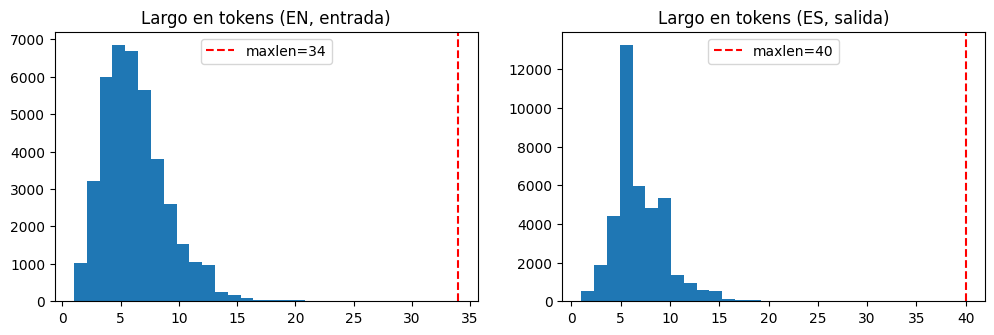

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(input_lens, bins=30)
axes[0].axvline(max_input_len, color='red', linestyle='--', label=f'maxlen={max_input_len}')
axes[0].set_title('Largo en tokens (EN, entrada)')
axes[0].legend()
axes[1].hist(output_lens, bins=30)
axes[1].axvline(max_out_len, color='red', linestyle='--', label=f'maxlen={max_out_len}')
axes[1].set_title('Largo en tokens (ES, salida)')
axes[1].legend()
plt.show()

In [28]:
# 1) ¿Cuánto medían los vocabularios con las 10.000 oraciones de clase?
#    (mismo shuffle y semilla: las primeras 10k de nuestras 40k son exactamente las de clase)
tok_es_10k = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')
tok_es_10k.fit_on_texts(["<sos>", "<eos>"] + output_sentences[:10000])   # el fit original de clase
tok_en_10k = Tokenizer(num_words=MAX_VOCAB_SIZE)
tok_en_10k.fit_on_texts(input_sentences[:10000])
print(f"Con 10k oraciones — vocab ES: {len(tok_es_10k.word_index)} | vocab EN: {len(tok_en_10k.word_index)}"
      f" | idx(<sos>) = {tok_es_10k.word_index['<sos>']} (entraba en las {MAX_VOCAB_SIZE})")

# 2) Con las 40k oraciones y el fit original de clase, ¿dónde caía <sos>?
tok_bug = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')
tok_bug.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
print(f"Con 40k oraciones y el fit de clase — idx(<sos>) = {tok_bug.word_index['<sos>']}"
      f" (fuera de las {MAX_VOCAB_SIZE}: el bug)")

# 3) ¿Hay pares exactos repetidos entre train y validación?
split_chk   = int(len(input_sentences) * 0.85)
train_pairs = set(zip(input_sentences[:split_chk], output_sentences[:split_chk]))
val_pairs   = list(zip(input_sentences[split_chk:], output_sentences[split_chk:]))
dup = sum(p in train_pairs for p in val_pairs)
print(f"Pares (EN, ES) de validación repetidos exactos en train: {dup} de {len(val_pairs)}")

Con 10k oraciones — vocab ES: 7803 | vocab EN: 4977 | idx(<sos>) = 3434 (entraba en las 8000)
Con 40k oraciones y el fit de clase — idx(<sos>) = 8346 (fuera de las 8000: el bug)
Pares (EN, ES) de validación repetidos exactos en train: 0 de 6000


### Conclusiones

La primera corrida del barrido dio `val_accuracy` 0,9993 y `val_loss` 0,0099, demasiado bueno para ser cierto. No era fuga de datos (chequeamos que hay cero pares repetidos entre train y validación), sino algo más sutil: al pasar de 10k a 40k oraciones el vocabulario español saltó de ~7.800 a 16.144 palabras, y `<sos>`, que en el fit de clase aparece una sola vez, quedó con índice 8.346, fuera de las 8.000 de `num_words`. `texts_to_sequences` lo eliminó sin avisar, la entrada del decoder quedó sin corrimiento respecto del target, y el modelo solo tenía que repetir el token que acababa de recibir. Lo interesante es que fallaron en silencio dos cosas encadenadas: el tokenizer descarta tokens sin avisar y el gather de GPU devuelve ceros para índices fuera de rango. Lo único que delató el problema fue una métrica sospechosamente perfecta. Los `assert` quedaron para que no vuelva a pasar.

Del escalado en sí: con 40.000 oraciones el vocabulario inglés pasó de ~5.000 a 9.120 palabras, así que ahora también hay palabras de entrada que quedan fuera de las 8.000 del tokenizer. Los largos máximos reales dieron 34/40 tokens contra los 20/22 fijados en clase; solo 35 oraciones se truncaban antes, pero ahora ninguna pierde tokens. El costo es el que muestra el histograma: la moda está en 5-7 tokens, así que con maxlen 40 cerca del 83 % de lo que ve el decoder es padding, y buena parte del cómputo por época se gasta en predecir ceros.

Aplicamos padding: `'pre'` para el encoder (así lo último que procesa la LSTM es la oración real y no ceros) y `'post'` para el decoder.

In [29]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

In [30]:
print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0  932 1082   18   95]
[   2  157 1127   23  209    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]
[ 157 1127   23  209    1    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]


## 4. Datasets de entrenamiento y validación

Misma función de clase: un `tf.data.Dataset` que arma los targets one-hot batch a batch. Con 40.000 oraciones y secuencias más largas, materializar el tensor completo `(N, max_out_len, 8000)` en RAM sería inviable, así que esto pasa de ser un detalle a ser obligatorio.

In [31]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):

    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)          # shape (max_out_len, num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

Separamos train y validación (85/15), igual que en clase.

In [32]:
BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

## 5. Embeddings GloVe

Igual que en clase: embeddings GloVe de 50 dimensiones, congelados, para el encoder (inglés). El decoder aprende sus embeddings desde cero.

In [33]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

gloveembedding.pkl ya disponible.


In [34]:
def load_glove_embeddings(pkl_path):
    """Carga el pickle de GloVe y devuelve (word2idx, matrix_fn)."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

In [35]:
def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

In [36]:
def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

Un detalle respecto de la versión de clase: acá usamos `len(word2idx_inputs) + 1` porque los índices del tokenizer arrancan en 1 (el 0 queda reservado para el padding), así que la palabra más rara tiene índice igual a `len(word2idx_inputs)` y necesita una fila más en la matriz. En GPU el lookup fuera de rango devuelve ceros en silencio, por eso el notebook de clase no falla, pero es mejor tener la matriz del tamaño correcto.

In [37]:
EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Embeddings nulos: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")

Embeddings nulos: 390


## 6. Modelo Seq2Seq

Mismas funciones de clase, con dos cambios para poder hacer el barrido:

- Un `tag` en los nombres de las capas, para poder construir varios modelos en la misma sesión sin colisiones de nombres.
- El embedding del decoder pasa a tener dimensión fija (256) en lugar de estar atado a `n_units`. Si no, al variar `n_units` estaríamos cambiando dos cosas a la vez y la comparación no mediría solo el ancho de las capas recurrentes.

In [38]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units, tag=''):

    enc_inputs   = Input(shape=(max_input_len,), name=f'encoder_inputs{tag}')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name=f'encoder_embedding{tag}'
    )
    enc_emb = Dropout(0.3, name=f'encoder_dropout{tag}')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name=f'encoder_lstm{tag}')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

In [39]:
def build_decoder(num_words_output, max_out_len, n_units, encoder_states,
                  dec_embed_dim=256, tag=''):

    dec_inputs = Input(shape=(max_out_len,), name=f'decoder_inputs{tag}')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=dec_embed_dim,
        input_length=max_out_len,
        name=f'decoder_embedding{tag}'
    )
    dec_emb = Dropout(0.3, name=f'decoder_dropout{tag}')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name=f'decoder_lstm{tag}')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name=f'decoder_dense{tag}')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

## 7. Barrido de unidades LSTM

Entrenamos tres configuraciones: **128, 256 y 512** unidades (256 es la de clase). Cada corrida usa los mismos callbacks de clase: `ReduceLROnPlateau` y `EarlyStopping` con `restore_best_weights=True`, hasta un máximo de 30 épocas.

⚠️ Las tres corridas juntas llevan un buen rato en una T4. Para no perder horas de GPU si Colab se desconecta, al terminar cada configuración guardamos los pesos y el history en Drive; al re-correr la celda del barrido, las configuraciones que ya tienen checkpoint se cargan de Drive en lugar de reentrenarse.

In [40]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CKPT_DIR = '/content/drive/MyDrive/ceia-nlp1/desafio_4'
except ImportError:
    CKPT_DIR = './checkpoints'  # fallback fuera de Colab

os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Checkpoints en: {CKPT_DIR}")

Mounted at /content/drive
Checkpoints en: /content/drive/MyDrive/ceia-nlp1/desafio_4


In [41]:
EPOCHS      = 30
UNITS_SWEEP = [128, 256, 512]

def train_config(n_units):
    tag    = f'_{n_units}'
    w_path = f'{CKPT_DIR}/traductor{tag}.weights.h5'
    h_path = f'{CKPT_DIR}/traductor{tag}.history.json'

    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units, tag=tag
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states, tag=tag
    )
    model = Model([enc_inputs, dec_inputs], dec_outputs)

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )

    if os.path.exists(w_path) and os.path.exists(h_path):
        print(f"Checkpoint encontrado ({w_path}): cargo pesos y salteo el entrenamiento")
        model.load_weights(w_path)
        with open(h_path) as f:
            saved = json.load(f)
        history, tiempo = saved['history'], saved['tiempo']
    else:
        callbacks = [
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
            EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ]
        t0      = time.time()
        hist    = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
        tiempo  = time.time() - t0
        history = {k: [float(v) for v in vals] for k, vals in hist.history.items()}

        model.save_weights(w_path)
        with open(h_path, 'w') as f:
            json.dump({'history': history, 'tiempo': tiempo}, f)
        print(f"Checkpoint guardado en {w_path}")

    return {
        'n_units': n_units, 'model': model, 'history': history, 'tiempo': tiempo,
        'enc_inputs': enc_inputs, 'enc_emb_layer': enc_emb_layer,
        'enc_lstm_layer': enc_lstm_layer, 'dec_emb_layer': dec_emb_layer,
        'dec_lstm_layer': dec_lstm_layer, 'dec_dense_layer': dec_dense_layer,
    }

In [42]:
results = {}
for n_units in UNITS_SWEEP:
    print(f"\n===== n_units = {n_units} =====")
    results[n_units] = train_config(n_units)


===== n_units = 128 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Checkpoint encontrado (/content/drive/MyDrive/ceia-nlp1/desafio_4/traductor_128.weights.h5): cargo pesos y salteo el entrenamiento


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== n_units = 256 =====
Checkpoint encontrado (/content/drive/MyDrive/ceia-nlp1/desafio_4/traductor_256.weights.h5): cargo pesos y salteo el entrenamiento

===== n_units = 512 =====
Checkpoint encontrado (/content/drive/MyDrive/ceia-nlp1/desafio_4/traductor_512.weights.h5): cargo pesos y salteo el entrenamiento


Comparamos las configuraciones. La métrica principal es `val_loss` en la mejor época; la accuracy incluye los tokens de padding, así que está inflada y sirve solo para comparar entre configuraciones.

In [43]:
rows = []
for n_units, r in results.items():
    h    = r['history']
    best = int(np.argmin(h['val_loss']))
    rows.append({
        'n_units':       n_units,
        'parametros':    r['model'].count_params(),
        'epocas':        len(h['val_loss']),
        'mejor_epoca':   best + 1,
        'seg_por_epoca': round(r['tiempo'] / len(h['val_loss']), 1),
        'val_loss':      round(h['val_loss'][best], 4),
        'val_accuracy':  round(h['val_accuracy'][best], 4),
    })

comparacion = pd.DataFrame(rows).sort_values('val_loss').reset_index(drop=True)
comparacion

,n_units,parametros,epocas,mejor_epoca,seg_por_epoca,val_loss,val_accuracy
0,512,9279936,30,28,68.9,0.4647,0.9167
1,256,5343680,30,30,55.5,0.4839,0.9118
2,128,3768768,30,30,59.3,0.5418,0.9010


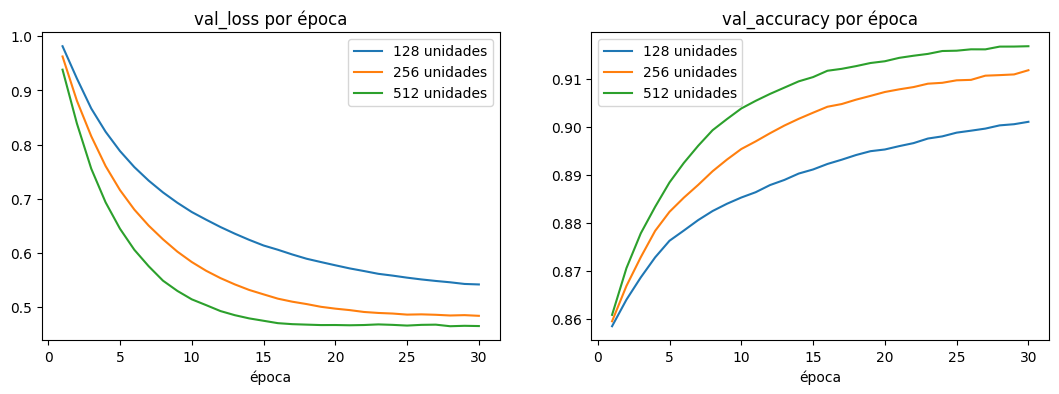

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for n_units, r in results.items():
    h  = r['history']
    ep = range(1, len(h['val_loss']) + 1)
    axes[0].plot(ep, h['val_loss'],     label=f'{n_units} unidades')
    axes[1].plot(ep, h['val_accuracy'], label=f'{n_units} unidades')

axes[0].set_title('val_loss por época')
axes[0].set_xlabel('época')
axes[0].legend()
axes[1].set_title('val_accuracy por época')
axes[1].set_xlabel('época')
axes[1].legend()
plt.show()

In [45]:
# Verificación de cuánto de la accuracy es padding.
pad_frac  = float((decoder_output_sequences == 0).mean())
mean_real = float((decoder_output_sequences != 0).sum(axis=1).mean())

h = results[512]['history']
b = int(np.argmin(h['val_loss']))
val_acc, val_loss = h['val_accuracy'][b], h['val_loss'][b]

# estimación: asume que el padding se acierta siempre (a esta altura del entrenamiento, casi exacto)
acc_real = (val_acc - pad_frac) / (1 - pad_frac)
ppl_real = float(np.exp(val_loss * max_out_len / mean_real))

print(f"Posiciones de padding en el decoder: {pad_frac:.1%}")
print(f"Tokens reales promedio por oración (incl. <eos>): {mean_real:.1f} de {max_out_len}")
print(f"val_accuracy 512 = {val_acc:.4f} -> accuracy sobre tokens reales ≈ {acc_real:.0%}")
print(f"val_loss 512 = {val_loss:.4f} -> perplejidad por token real ≈ {ppl_real:.0f}")

Posiciones de padding en el decoder: 82.8%
Tokens reales promedio por oración (incl. <eos>): 6.9 de 40
val_accuracy 512 = 0.9167 -> accuracy sobre tokens reales ≈ 52%
val_loss 512 = 0.4647 -> perplejidad por token real ≈ 15


### Conclusiones

Se observa un orden claro: 512 unidades dan `val_loss` 0,4647, 256 dan 0,4839 y 128 dan 0,5418. Pero los rendimientos son bien decrecientes: duplicar de 128 a 256 mejora 0,058, y volver a duplicar solo 0,019. En parámetros esa última duplicación cuesta caro (9,3 millones contra 5,3), aunque en tiempo la T4 casi ni se entera: 55-69 segundos por época en las tres configuraciones, probablemente debido a que el ancho extra se paraleliza bien en GPU.

Las corridas de 128 y 256 terminaron las 30 épocas todavía mejorando: su mejor época fue la última y el `ReduceLROnPlateau` nunca saltó, así que no sabemos dónde está su techo. 512, en cambio, sí convergió: se amesetó cerca de la época 17, el learning rate se recortó tres veces y la mejor época fue la 28. En parte estamos midiendo quién aprende más rápido con 30 épocas de presupuesto, y el que ganó es también el único que llegó a converger, así que es difícil que el orden se dé vuelta con más épocas.

Sobre la accuracy: 0,9167 parece espectacular pero el 82,8 % de las posiciones del decoder son padding y se predicen gratis. Descontándolo, el modelo de 512 acierta el 52 % de las palabras reales - y con teacher forcing. Por eso la comparación va por `val_loss`. Ahí también se ve algo de sobreajuste en el 512: train loss 0,186 contra val loss 0,465. Con este tamaño de modelo, lo que empieza a faltar son datos, no capacidad.

## 8. Inferencia

Mismos modelos de inferencia de clase (un encoder que devuelve los estados y un decoder que predice de a un token), construidos para cada configuración del barrido. La decodificación es greedy: en cada paso se toma el token más probable.

In [46]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)                    # reutiliza pesos entrenados
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Modelo de decoder paso a paso (un token por vez)."""
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)      # reutiliza pesos entrenados
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )

In [47]:
for n_units, r in results.items():
    r['encoder_model'] = build_encoder_inference(
        r['enc_inputs'], r['enc_emb_layer'], r['enc_lstm_layer'], n_units
    )
    r['decoder_model'] = build_decoder_inference(
        r['dec_emb_layer'], r['dec_lstm_layer'], r['dec_dense_layer'], n_units
    )

idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

In [48]:
def translate_sentence(input_seq, encoder_model, decoder_model):
    h, c = encoder_model.predict(input_seq, verbose=0)    # desempaqueta directo
    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c], verbose=0                 # estados como args separados
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text, encoder_model, decoder_model):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq, encoder_model, decoder_model)

## 9. Ejemplos de traducción

Traducimos con el mejor modelo del barrido: 5 oraciones del conjunto de validación (que el modelo no vio durante el entrenamiento) y 5 frases nuevas. Después comparamos las tres configuraciones sobre las mismas frases.

In [49]:
best_units = int(comparacion.iloc[0]['n_units'])
best       = results[best_units]
print(f"Mejor configuración: {best_units} unidades\n")

rng = np.random.default_rng(7)
print("--- Ejemplos del set de validación ---")
for i in rng.choice(np.arange(split_idx, len(input_sentences)), size=5, replace=False):
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq, best['encoder_model'], best['decoder_model'])
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- Frases nuevas ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?",
          "The weather is very cold today."]:
    print(f"EN: {s}")
    print(f"ES: {translate(s, best['encoder_model'], best['decoder_model'])}\n")

Mejor configuración: 512 unidades

--- Ejemplos del set de validación ---
EN: There is no doubt about his honesty.
ES (real): No hay duda de su honradez.
ES (pred): no hay nada de lo que él tenga sentido

EN: This is neither new nor unknown.
ES (real): Esto no es nuevo ni desconocido.
ES (pred): este es el ejemplo de esa manera

EN: Can you tell butter from margarine?
ES (real): ¿Sabes distinguir la mantequilla de la margarina?
ES (pred): puedes pasarme la sal y las

EN: I can see Tom.
ES (real): Puedo ver a Tom.
ES (pred): puedo ver a tom

EN: Rosa Parks refused to give up her seat for a white passenger.
ES (real): Rosa Parks se negó a dejar su asiento a un pasajero de raza blanca.
ES (pred): la policía se ofreció a su asiento y un

--- Frases nuevas ---
EN: My mother says hi.
ES: mi madre llama a mi padre

EN: Where is the train station?
ES: dónde está la estación más cercana

EN: I love learning languages.
ES: me encanta estudiar japonés

EN: Can you help me?
ES: puedes ayudarme

EN

Comparamos las tres configuraciones sobre las mismas frases, para ver si la diferencia de métricas se nota también en la calidad de las traducciones.

In [50]:
frases = [
    "I want to go home.",
    "She is reading a book in the garden.",
    "We didn't have enough time to finish the work.",
]

for s in frases:
    print(f"EN: {s}")
    for n_units, r in results.items():
        print(f"  {n_units:>4} unidades: {translate(s, r['encoder_model'], r['decoder_model'])}")
    print()

EN: I want to go home.
   128 unidades: quiero ir a casa


   256 unidades: quiero ir a casa
   512 unidades: quiero ir a casa

EN: She is reading a book in the garden.
   128 unidades: ella es una revista en la biblioteca
   256 unidades: ella está leyendo un libro en la biblioteca
   512 unidades: ella está leyendo un libro en la biblioteca

EN: We didn't have enough time to finish the work.
   128 unidades: no tenemos tiempo para terminar el trabajo
   256 unidades: no tenemos tiempo para terminar el trabajo
   512 unidades: no tenemos tiempo para terminar el trabajo



In [51]:
# Lado de salida (ES): la traducción natural de "says hi" sería "saluda";
# y el error garden -> "biblioteca" no se explica por vocabulario.
for w in ['madre', 'llama', 'saluda', 'jardín', 'biblioteca']:
    idx    = word2idx_outputs.get(w)
    dentro = idx is not None and idx < num_words_output
    print(f"ES {w!r}: índice {idx} -> {'dentro' if dentro else 'FUERA'} del vocabulario efectivo ({num_words_output} palabras)")

# Lado de entrada (EN): el encoder sí ve estas palabras; el problema no está en la entrada.
for w in ['hi', 'garden']:
    idx    = word2idx_inputs.get(w)
    dentro = idx is not None and idx < nb_words
    print(f"EN {w!r}: índice {idx} -> {'dentro' if dentro else 'FUERA'} del vocabulario efectivo ({nb_words} palabras)")

ES 'madre': índice 155 -> dentro del vocabulario efectivo (8000 palabras)
ES 'llama': índice 616 -> dentro del vocabulario efectivo (8000 palabras)
ES 'saluda': índice 13248 -> FUERA del vocabulario efectivo (8000 palabras)
ES 'jardín': índice 679 -> dentro del vocabulario efectivo (8000 palabras)
ES 'biblioteca': índice 641 -> dentro del vocabulario efectivo (8000 palabras)
EN 'hi': índice 2053 -> dentro del vocabulario efectivo (8000 palabras)
EN 'garden': índice 788 -> dentro del vocabulario efectivo (8000 palabras)


### Conclusiones

De esta sección podemos sacar un patrón: las frases cortas y frecuentes salen impecables ("I can see Tom" → "puedo ver a tom", "Can you help me?" → "puedes ayudarme", y las tres configuraciones clavan "quiero ir a casa"). En cuanto la frase se aleja de lo frecuente, el modelo no dice cualquier cosa, sino que dice otra cosa plausible. "I love learning languages" → "me encanta estudiar japonés", "Where is the train station?" → "dónde está la estación más cercana", "My mother says hi" → "mi madre llama a mi padre". Son sustituciones por vecinos semánticos: cuando la señal del encoder no alcanza, el decoder completa con la colocación más frecuente del corpus.

La traducción natural de "My mother says hi." sería "mi madre saluda", pero "saluda" quedó con el índice 13.248 en la tabla de frecuencias, fuera de las 8.000 palabras del vocabulario de salida: la traducción correcta era directamente imposible de generar, sin importar la estrategia de decodificación.

Con oraciones largas la cosa se degrada en serio: "Rosa Parks refused to give up her seat..." termina en "la policía se ofreció a su asiento y un", que conserva fragmentos del tema pero pierde el hilo.

La comparación entre configuraciones muestra que la diferencia de métrica se ve en la calidad: en "She is reading a book in the garden", el de 128 inventa ("ella es una revista en la biblioteca") mientras que 256 y 512 sacan bien la estructura. Eso sí, los tres dicen "biblioteca" en vez de "jardín" — y "jardín" está en el vocabulario: simplemente "leer un libro en la biblioteca" pesa más en el dataset que la fidelidad a la fuente.

## 10. (Opcional) Embeddings preentrenados en ambos idiomas

El encoder ya usa GloVe preentrenado (inglés, 50d, congelado); el decoder venía aprendiendo sus embeddings desde cero. Acá le damos fastText en español (`cc.es.300`, entrenado sobre Common Crawl). El archivo viene ordenado por frecuencia, así que en lugar de bajar y cargar los 2 GB completos, streameamos la descarga y nos quedamos con los primeros 200.000 vectores, que sobran para cubrir nuestras 8.000 palabras más frecuentes.

A diferencia del encoder, acá el embedding queda **entrenable**: `<sos>`, `<eos>` y las palabras sin vector arrancan en cero y necesitan ajustarse, y el rol de un embedding en generación no es idéntico al de representación. El experimento compara el mejor modelo del barrido (512 unidades, embedding del decoder desde cero) contra la misma arquitectura con el decoder inicializado con fastText.

In [52]:
FT_ES_HEAD = 'cc.es.300.head.vec'
FT_DIM     = 300

if not os.path.exists(FT_ES_HEAD):
    print("Descargando (parcialmente) fastText cc.es.300...")
    # head corta el pipe después de 200k líneas: se descarga solo lo necesario
    os.system("curl -sL https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz"
              " | gunzip -c 2>/dev/null | head -n 200001 > " + FT_ES_HEAD)
    print("Listo.")

dec_embedding_matrix = np.zeros((num_words_output, FT_DIM), dtype='float32')
found = 0
with open(FT_ES_HEAD, encoding='utf-8', errors='ignore') as f:
    next(f)  # header del archivo (cantidad y dimensión)
    for line in f:
        parts = line.rstrip().split(' ')
        if len(parts) != FT_DIM + 1:
            continue
        i = word2idx_outputs.get(parts[0])
        if i is not None and i < num_words_output and not dec_embedding_matrix[i].any():
            dec_embedding_matrix[i] = np.asarray(parts[1:], dtype='float32')
            found += 1

print(f"Cobertura fastText: {found}/{num_words_output} palabras del vocabulario ES "
      f"({num_words_output - found} quedan en cero, incluidos <sos>, <eos> y padding)")

Descargando (parcialmente) fastText cc.es.300...
Listo.
Cobertura fastText: 7689/8000 palabras del vocabulario ES (311 quedan en cero, incluidos <sos>, <eos> y padding)


In [53]:
def build_decoder_pretrained(num_words_output, max_out_len, n_units, encoder_states,
                             dec_embedding_matrix, tag=''):

    dec_inputs = Input(shape=(max_out_len,), name=f'decoder_inputs{tag}')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=dec_embedding_matrix.shape[1],
        weights=[dec_embedding_matrix],
        trainable=True,                       # se ajusta durante el entrenamiento
        name=f'decoder_embedding{tag}'
    )
    dec_emb = Dropout(0.3, name=f'decoder_dropout{tag}')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name=f'decoder_lstm{tag}')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name=f'decoder_dense{tag}')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

In [54]:
N_UNITS_FT = 512
tag_ft = f'_{N_UNITS_FT}_ftES'
w_path = f'{CKPT_DIR}/traductor{tag_ft}.weights.h5'
h_path = f'{CKPT_DIR}/traductor{tag_ft}.history.json'

enc_i, enc_s, enc_e, enc_l = build_encoder(
    nb_words, EMBED_DIM, embedding_matrix, max_input_len, N_UNITS_FT, tag=tag_ft
)
dec_i, dec_o, dec_e, dec_lc, dec_d = build_decoder_pretrained(
    num_words_output, max_out_len, N_UNITS_FT, enc_s, dec_embedding_matrix, tag=tag_ft
)
model_ft = Model([enc_i, dec_i], dec_o)
model_ft.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

if os.path.exists(w_path) and os.path.exists(h_path):
    print(f"Checkpoint encontrado ({w_path}): cargo pesos y salteo el entrenamiento")
    model_ft.load_weights(w_path)
    with open(h_path) as f:
        saved = json.load(f)
    history_ft, tiempo_ft = saved['history'], saved['tiempo']
else:
    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ]
    t0         = time.time()
    hist_ft    = model_ft.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
    tiempo_ft  = time.time() - t0
    history_ft = {k: [float(v) for v in vals] for k, vals in hist_ft.history.items()}
    model_ft.save_weights(w_path)
    with open(h_path, 'w') as f:
        json.dump({'history': history_ft, 'tiempo': tiempo_ft}, f)
    print(f"Checkpoint guardado en {w_path}")

ft_result = {
    'n_units': N_UNITS_FT, 'model': model_ft, 'history': history_ft, 'tiempo': tiempo_ft,
    'encoder_model': build_encoder_inference(enc_i, enc_e, enc_l, N_UNITS_FT),
    'decoder_model': build_decoder_inference(dec_e, dec_lc, dec_d, N_UNITS_FT),
}

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Checkpoint encontrado (/content/drive/MyDrive/ceia-nlp1/desafio_4/traductor_512_ftES.weights.h5): cargo pesos y salteo el entrenamiento


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


512 baseline      : val_loss 0.4647 (mejor época 28, 9,722,048 params c/fastText)
512 + fastText ES : val_loss 0.4670 (mejor época 21)


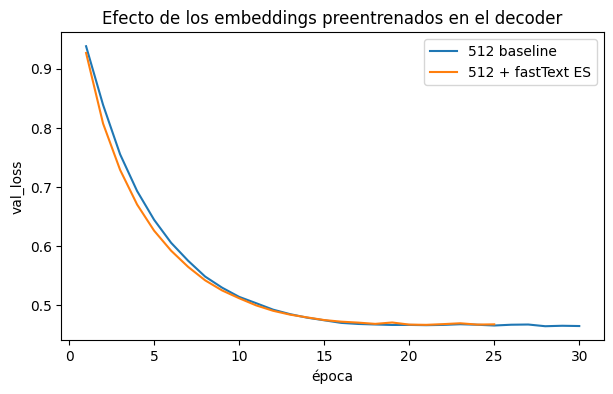

EN: My mother says hi.
  baseline : mi madre llama a mi padre
  fastText : mi madre me llama

EN: Where is the train station?
  baseline : dónde está la estación más cercana
  fastText : dónde está el tren de tren

EN: I love learning languages.
  baseline : me encanta estudiar japonés
  fastText : me encantan los lenguas extranjeras

EN: She is reading a book in the garden.
  baseline : ella está leyendo un libro en la biblioteca
  fastText : ella está leyendo una revista en la biblioteca

EN: The weather is very cold today.
  baseline : el invierno está muy frío hoy
  fastText : hoy es muy frío hoy



In [55]:
h_base, h_ft = best['history'], ft_result['history']
print(f"512 baseline      : val_loss {min(h_base['val_loss']):.4f} "
      f"(mejor época {int(np.argmin(h_base['val_loss'])) + 1}, {model_ft.count_params():,} params c/fastText)")
print(f"512 + fastText ES : val_loss {min(h_ft['val_loss']):.4f} "
      f"(mejor época {int(np.argmin(h_ft['val_loss'])) + 1})")

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(h_base['val_loss']) + 1), h_base['val_loss'], label='512 baseline')
plt.plot(range(1, len(h_ft['val_loss']) + 1),   h_ft['val_loss'],   label='512 + fastText ES')
plt.xlabel('época'); plt.ylabel('val_loss'); plt.legend()
plt.title('Efecto de los embeddings preentrenados en el decoder')
plt.show()

for s in ["My mother says hi.", "Where is the train station?", "I love learning languages.",
          "She is reading a book in the garden.", "The weather is very cold today."]:
    print(f"EN: {s}")
    print(f"  baseline : {translate(s, best['encoder_model'], best['decoder_model'])}")
    print(f"  fastText : {translate(s, ft_result['encoder_model'], ft_result['decoder_model'])}")
    print()

### Conclusiones

La cobertura fue excelente (7.689 de 8.000 palabras, el 96 %) y aun así el resultado es un empate: `val_loss` 0,4670 contra 0,4647 del baseline. Lo único que compró fastText fue velocidad de arranque: la curva naranja va un paso adelante durante las primeras diez épocas (0,63 contra 0,64 en la época 5) y el modelo convergió antes (mejor época 21 y early stopping en la 25, contra mejor época 28 del baseline).

En las traducciones tampoco hay mejora. Es más, encontramos algunos errores: "el tren de tren", "hoy es muy frío hoy", "me encantan **los** lenguas extranjeras", errores que el baseline no comete. Ninguno de los errores típicos que veníamos viendo se arregló.

Se concluye que el preentrenamiento aporta un buen punto de partida, pero no información que el modelo no pueda sacar solo. Y el cuello de botella del traductor no está en cómo representa las palabras españolas que ya decidió generar, sino en lo que llega (o no llega) desde el encoder.

## 11. (Opcional) fastText inglés para el encoder

En la sección anterior mejoramos el embedding del decoder y no pasó nada. El del encoder es otra historia: es la única puerta de entrada del significado, son vectores de apenas 50 dimensiones y están **congelados** — le estamos pidiendo a una LSTM de 512 unidades que lea toda la oración a través de una señal fija de 50 números. Acá reemplazamos GloVe 50d por fastText inglés (`cc.en.300`, misma descarga parcial que usamos para el español) en dos variantes: **congelado**, como el baseline, y **entrenable** (fine-tuning), que es el otro hiperparámetro escondido en esa capa. El decoder vuelve a ser el del baseline (256d aprendidas desde cero), así el experimento mide solo el cambio en el encoder.

⚠️ Son dos entrenamientos más de ~35 minutos cada uno en la T4, cada uno con su checkpoint en Drive.

In [56]:
FT_EN_HEAD = 'cc.en.300.head.vec'
FT_DIM_EN  = 300

if not os.path.exists(FT_EN_HEAD):
    print("Descargando (parcialmente) fastText cc.en.300...")
    os.system("curl -sL https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz"
              " | gunzip -c 2>/dev/null | head -n 200001 > " + FT_EN_HEAD)
    print("Listo.")

enc_ft_matrix = np.zeros((nb_words, FT_DIM_EN), dtype='float32')
found = 0
with open(FT_EN_HEAD, encoding='utf-8', errors='ignore') as f:
    next(f)  # header del archivo
    for line in f:
        parts = line.rstrip().split(' ')
        if len(parts) != FT_DIM_EN + 1:
            continue
        i = word2idx_inputs.get(parts[0])
        if i is not None and i < nb_words and not enc_ft_matrix[i].any():
            enc_ft_matrix[i] = np.asarray(parts[1:], dtype='float32')
            found += 1

print(f"Cobertura fastText EN: {found}/{nb_words} palabras del vocabulario "
      f"({nb_words - found} quedan en cero)")

Descargando (parcialmente) fastText cc.en.300...
Listo.
Cobertura fastText EN: 7613/8000 palabras del vocabulario (387 quedan en cero)


In [57]:
def build_encoder_pretrained(nb_words, embed_matrix, max_input_len, n_units,
                             trainable, tag=''):

    enc_inputs = Input(shape=(max_input_len,), name=f'encoder_inputs{tag}')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_matrix.shape[1],
        weights=[embed_matrix],
        trainable=trainable,
        name=f'encoder_embedding{tag}'
    )
    enc_emb = Dropout(0.3, name=f'encoder_dropout{tag}')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name=f'encoder_lstm{tag}')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

In [58]:
N_UNITS_FTEN = 512
ften_results = {}

for nombre, entrenable in [('congelado', False), ('entrenable', True)]:
    tag    = f'_{N_UNITS_FTEN}_ftEN_{nombre}'
    w_path = f'{CKPT_DIR}/traductor{tag}.weights.h5'
    h_path = f'{CKPT_DIR}/traductor{tag}.history.json'
    print(f"\n===== encoder fastText EN ({nombre}) =====")

    enc_i, enc_s, enc_e, enc_l = build_encoder_pretrained(
        nb_words, enc_ft_matrix, max_input_len, N_UNITS_FTEN, entrenable, tag=tag
    )
    dec_i, dec_o, dec_e, dec_lc, dec_d = build_decoder(
        num_words_output, max_out_len, N_UNITS_FTEN, enc_s, tag=tag
    )
    m = Model([enc_i, dec_i], dec_o)
    m.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )

    if os.path.exists(w_path) and os.path.exists(h_path):
        print(f"Checkpoint encontrado ({w_path}): cargo pesos y salteo el entrenamiento")
        m.load_weights(w_path)
        with open(h_path) as f:
            saved = json.load(f)
        history, tiempo = saved['history'], saved['tiempo']
    else:
        callbacks = [
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
            EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ]
        t0      = time.time()
        hist    = m.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
        tiempo  = time.time() - t0
        history = {k: [float(v) for v in vals] for k, vals in hist.history.items()}
        m.save_weights(w_path)
        with open(h_path, 'w') as f:
            json.dump({'history': history, 'tiempo': tiempo}, f)
        print(f"Checkpoint guardado en {w_path}")

    ften_results[nombre] = {
        'model': m, 'history': history, 'tiempo': tiempo,
        'encoder_model': build_encoder_inference(enc_i, enc_e, enc_l, N_UNITS_FTEN),
        'decoder_model': build_decoder_inference(dec_e, dec_lc, dec_d, N_UNITS_FTEN),
    }


===== encoder fastText EN (congelado) =====
Checkpoint encontrado (/content/drive/MyDrive/ceia-nlp1/desafio_4/traductor_512_ftEN_congelado.weights.h5): cargo pesos y salteo el entrenamiento

===== encoder fastText EN (entrenable) =====
Checkpoint encontrado (/content/drive/MyDrive/ceia-nlp1/desafio_4/traductor_512_ftEN_entrenable.weights.h5): cargo pesos y salteo el entrenamiento


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [59]:
modelos = {
    'baseline (GloVe 50 congelado)': best,
    'fastText ES en el decoder':     ft_result,
    'fastText EN congelado':         ften_results['congelado'],
    'fastText EN entrenable':        ften_results['entrenable'],
}

rows = []
for nombre, r in modelos.items():
    h = r['history']
    b = int(np.argmin(h['val_loss']))
    rows.append({
        'modelo':       nombre,
        'parametros':   r['model'].count_params(),
        'epocas':       len(h['val_loss']),
        'mejor_epoca':  b + 1,
        'val_loss':     round(h['val_loss'][b], 4),
        'val_accuracy': round(h['val_accuracy'][b], 4),
    })

pd.DataFrame(rows).sort_values('val_loss').reset_index(drop=True)

,modelo,parametros,epocas,mejor_epoca,val_loss,val_accuracy
0,fastText EN entrenable,11791936,25,21,0.4502,0.9215
1,baseline (GloVe 50 congelado),9279936,30,28,0.4647,0.9167
2,fastText ES en el decoder,9722048,25,21,0.4670,0.9141
3,fastText EN congelado,11791936,30,28,0.4950,0.9136


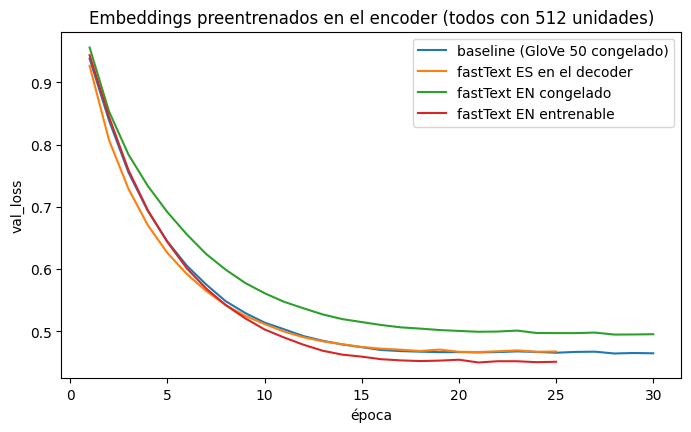

EN: My mother says hi.
  baseline (GloVe 50 congelado) : mi madre llama a mi padre
  fastText ES en el decoder     : mi madre me llama
  fastText EN congelado         : mi esposa me llamó a mi madre
  fastText EN entrenable        : mi madre me dice que está hablando

EN: Where is the train station?
  baseline (GloVe 50 congelado) : dónde está la estación más cercana
  fastText ES en el decoder     : dónde está el tren de tren
  fastText EN congelado         : dónde está el tren de tren
  fastText EN entrenable        : dónde está el tren de tren

EN: I love learning languages.
  baseline (GloVe 50 congelado) : me encanta estudiar japonés
  fastText ES en el decoder     : me encantan los lenguas extranjeras
  fastText EN congelado         : me encantan las lenguas extranjeras
  fastText EN entrenable        : me encanta aprender idiomas

EN: She is reading a book in the garden.
  baseline (GloVe 50 congelado) : ella está leyendo un libro en la biblioteca
  fastText ES en el decoder    

In [60]:
plt.figure(figsize=(8, 4.5))
for nombre, r in modelos.items():
    h = r['history']
    plt.plot(range(1, len(h['val_loss']) + 1), h['val_loss'], label=nombre)
plt.xlabel('época'); plt.ylabel('val_loss'); plt.legend()
plt.title('Embeddings preentrenados en el encoder (todos con 512 unidades)')
plt.show()

for s in ["My mother says hi.", "Where is the train station?", "I love learning languages.",
          "She is reading a book in the garden.", "The weather is very cold today."]:
    print(f"EN: {s}")
    for nombre, r in modelos.items():
        print(f"  {nombre:<30}: {translate(s, r['encoder_model'], r['decoder_model'])}")
    print()

### Conclusiones

La hipótesis era que el embedding del encoder era el eslabón débil, y resultó cierta — pero no por la razón que esperábamos. La variante **congelada** de 300 dimensiones dio 0,4950 de `val_loss`: seis veces más dimensiones que el GloVe de 50 del baseline y un resultado claramente *peor* (el baseline daba 0,4647). En cambio la variante **entrenable** dio 0,4502, el mejor modelo de todo el desafío. O sea que el hiperparámetro que importaba en esa capa no era el tamaño sino `trainable`: el problema no era que 50 números fueran pocos, sino que estaban fijos. Tiene lógica que congelar duela más en 300d que en 50d: cuantas más dimensiones ajenas a la tarea le llegan a la LSTM, más trabajo tiene que hacer para filtrar lo que no le sirve, sin poder rotar el espacio a su favor.

La mejora del entrenable es real pero modesta: 0,0145, del mismo orden que la última duplicación de unidades del barrido (0,019). Y vino con la convergencia más rápida de todas (mejor época 21, early stopping en la 25) y la mejor `val_accuracy` (0,9215). El costo esperable también apareció: con 11,8 millones de parámetros y el embedding libre, la brecha train/val se agrandó (0,13 contra 0,45) — este modelo memoriza más que ninguno, y la cura sigue siendo más datos.

En las traducciones la mejora se nota apenas: el entrenable es el primer modelo del desafío que traduce bien "I love learning languages" → "me encanta aprender idiomas", y en "says hi" se acerca más que nadie ("mi madre me dice..."). Pero "garden" sigue perdido (ahora en un restaurante) y "train station" empeoró en las tres variantes con fastText ("el tren de tren").

## 12. (Opcional) Estrategias de generación: sampling y beam search

Hasta acá la decodificación fue **greedy**: en cada paso se toma el token más probable, sin posibilidad de deshacer una mala decisión. Probamos dos alternativas sobre el mismo decoder paso a paso:

- **Muestreo con temperatura**: en lugar del argmax, se muestrea de la distribución softmax. Con `T` baja se parece a greedy; con `T` alta gana diversidad (y riesgo de incoherencia).
- **Beam search**: se mantienen `k` hipótesis en paralelo y en cada paso se expanden y se conservan las `k` mejores por log-probabilidad normalizada por largo. Puede encontrar secuencias globalmente más probables que la cadena de decisiones locales de greedy.

In [61]:
def translate_sampling(text, encoder_model, decoder_model, temperature=1.0, seed=None):
    rng  = np.random.default_rng(seed)
    seq  = pad_sequences(input_tokenizer.texts_to_sequences([text]), maxlen=max_input_len)
    h, c = encoder_model.predict(seq, verbose=0)
    tok, eos = word2idx_outputs['<sos>'], word2idx_outputs['<eos>']

    palabras = []
    for _ in range(max_out_len):
        out, h, c = decoder_model.predict([np.array([[tok]]), h, c], verbose=0)
        logits = np.log(out[0, 0] + 1e-10) / temperature
        p = np.exp(logits - logits.max())
        p /= p.sum()
        tok = int(rng.choice(len(p), p=p))
        if tok == eos:
            break
        if tok > 0:
            palabras.append(idx2word_target[tok])
    return ' '.join(palabras)


def translate_beam(text, encoder_model, decoder_model, k=3, alpha=0.7):
    seq  = pad_sequences(input_tokenizer.texts_to_sequences([text]), maxlen=max_input_len)
    h, c = encoder_model.predict(seq, verbose=0)
    sos, eos = word2idx_outputs['<sos>'], word2idx_outputs['<eos>']

    beams  = [([sos], 0.0, False)]   # (tokens, logp acumulada, terminó)
    states = [(h, c)]
    for _ in range(max_out_len):
        candidatos, nuevos_estados = [], []
        for (tokens, logp, done), (bh, bc) in zip(beams, states):
            if done:
                candidatos.append((tokens, logp, True))
                nuevos_estados.append((bh, bc))
                continue
            out, h2, c2 = decoder_model.predict([np.array([[tokens[-1]]]), bh, bc], verbose=0)
            logprobs = np.log(out[0, 0] + 1e-10)
            for t in np.argsort(logprobs)[-k:]:
                candidatos.append((tokens + [int(t)], logp + logprobs[t], int(t) == eos))
                nuevos_estados.append((h2, c2))
        orden  = sorted(range(len(candidatos)),
                        key=lambda j: candidatos[j][1] / len(candidatos[j][0]) ** alpha,
                        reverse=True)[:k]
        beams  = [candidatos[j] for j in orden]
        states = [nuevos_estados[j] for j in orden]
        if all(b[2] for b in beams):
            break

    tokens, logp, _ = beams[0]
    palabras = [idx2word_target[t] for t in tokens[1:] if t not in (0, eos)]
    return ' '.join(palabras), logp / max(len(tokens) - 1, 1)

In [62]:
# Generamos con el mejor de todos los modelos entrenados en el desafío
candidatos = {
    '512 baseline':                 best,
    '512 + fastText ES (decoder)':  ft_result,
    '512 + fastText EN entrenable': ften_results['entrenable'],
}
nombre_gen, gen = min(candidatos.items(), key=lambda kv: min(kv[1]['history']['val_loss']))
print(f"Generamos con: {nombre_gen} (val_loss {min(gen['history']['val_loss']):.4f})\n")

for s in ["My mother says hi.", "Where is the train station?",
          "She is reading a book in the garden.",
          "We didn't have enough time to finish the work."]:
    print(f"EN: {s}")
    print(f"  greedy          : {translate(s, gen['encoder_model'], gen['decoder_model'])}")
    for k in (3, 5):
        t, lp = translate_beam(s, gen['encoder_model'], gen['decoder_model'], k=k)
        print(f"  beam k={k}        : {t}   (logp/token = {lp:.3f})")
    for T in (0.7, 1.0):
        for seed in (1, 2):
            t = translate_sampling(s, gen['encoder_model'], gen['decoder_model'], temperature=T, seed=seed)
            print(f"  sampling T={T} s{seed}: {t}")
    print()

Generamos con: 512 + fastText EN entrenable (val_loss 0.4502)

EN: My mother says hi.
  greedy          : mi madre me dice que está hablando
  beam k=3        : mi madre dice que yo quiera   (logp/token = -0.733)
  beam k=5        : mi madre dice que yo quiera   (logp/token = -0.733)
  sampling T=0.7 s1: mi madre me llamó a alguien
  sampling T=0.7 s2: mi madre dice que yo quiera
  sampling T=1.0 s1: mi esposa no ama
  sampling T=1.0 s2: mi madre sigue a alguna parte

EN: Where is the train station?
  greedy          : dónde está el tren de tren
  beam k=3        : dónde está el tren de tren   (logp/token = -0.338)
  beam k=5        : dónde está el tren de tren   (logp/token = -0.338)
  sampling T=0.7 s1: dónde queda la entrada el tren
  sampling T=0.7 s2: dónde está el tren de tren
  sampling T=1.0 s1: dónde queda la salida a el tren
  sampling T=1.0 s2: dónde está el tren por viene

EN: She is reading a book in the garden.
  greedy          : ella está leyendo un libro en un restaura

### Conclusiones

Con el mejor modelo del desafío (512 + fastText EN entrenable), beam search con 3 y con 5 haces devolvió **exactamente lo mismo que greedy** en dos de las cuatro frases, con la misma log-probabilidad. Y no es casualidad cuáles: son las de distribución más concentrada, donde el mejor token local es también el mejor global y no hay nada que rescatar. Es el contraste interesante con el desafío 3: allá greedy se metía en bucles y beam lo sacaba; acá las secuencias son de 5 a 8 tokens, el `<eos>` está bien aprendido, y greedy casi no comete errores de búsqueda.

Las dos frases donde sí divergen son las más reveladoras, y las dos terminan igual de mal. En "My mother says hi." —de nuevo la frase con peor log-probabilidad, -0,733 por token contra los -0,34/-0,49 del resto— greedy dice "mi madre me dice que está hablando" y beam encuentra "mi madre dice que yo quiera": más probable, no más correcta (la traducción correcta sigue siendo imposible: "saluda" no está en el vocabulario). En "garden", greedy manda el libro a un restaurante y beam a "en inglés". Un detalle positivo es que greedy ya dice solo "no tenemos tiempo **suficiente** para terminar el trabajo" — con el baseline, ese "enough" no aparecía.

En cuanto al sampling, con T=0,7 las variantes se mantienen plausibles (una semilla hasta corrige el tiempo verbal: "no **teníamos** tiempo...", que es lo que pide el "didn't"); con T=1,0 aparecen los errores ("dónde está el tren por viene", "está escribiendo un libro en el libro"). Y en la última frase las salidas con T=1,0 son idénticas a las de T=0,7 para cada semilla: ahí la distribución está tan concentrada que la temperatura casi no tiene de dónde sacar diversidad. La conclusión es la misma: la estrategia de generación puede corregir errores *de búsqueda*, pero acá casi no hay; los errores son *de conocimiento*, y esos no se arreglan decodificando distinto.

## 13. Conclusiones finales

A continuación se escriben las principales conclusiones obtenidas de las distintas iteraciones del traductor.

La primera corrida daba 99,9 % de accuracy de validación, lo cual resultó muy sospechoso. Se descubrió que escalar el dataset había roto el pipeline en silencio (el `<sos>` quedó fuera del vocabulario efectivo y la tarea degeneró en copiar el token anterior). El segundo punto de interés involucra al padding: incluso con el bug corregido, la accuracy "de 91,7 %" es en realidad un 52 % de aciertos sobre palabras reales, porque el 83 % de las posiciones son relleno. La `val_loss`, que es lo que usamos para comparar, equivale a una perplejidad de ~15 por palabra real: razonable para un seq2seq chico, lejos de un traductor utilizable.

Del barrido quedó que el ancho de la LSTM ayuda con rendimientos decrecientes (0,058 de mejora al duplicar de 128 a 256, solo 0,019 al volver a duplicar) y que el de 512 fue el único que convergió dentro de las 30 épocas: los otros dos se quedaron sin presupuesto antes que sin margen. También quedó a la vista el límite del ganador: train loss 0,19 contra val loss 0,46 es memorización, y la cura sería más datos antes que más red.

Las traducciones resumen bien qué aprende y qué no aprende este enfoque. Casi todas las salidas del modelo son español gramatical, pero ante frases poco frecuentes sustituye por el vecino estadístico ("estudiar japonés" por "learning languages") y ante oraciones largas pierde el hilo. Las limitaciones de fondo son tres, y las tres son estructurales: todo el significado comprimido en un estado de tamaño fijo (sin atención), decodificación greedy que no puede deshacer una mala decisión, y un vocabulario recortado a 8.000 palabras que vuelve imposibles algunas traducciones (a "saluda" ni siquiera puede nombrarla).

De las tareas opcionales, dos de los tres experimentos no consiguieron mejores resultados. El decoder preentrenado empató (0,467) y beam search no le ganó a greedy: donde coincidieron no había errores de búsqueda que corregir, y donde divergieron encontró secuencias más probables pero igual de erradas. Lo que sí resultó en mejores métricas fue reemplazar el GloVe de 50d congelado por fastText de 300d entrenable, que dio el mejor modelo del desafío (0,4502). La misma matriz congelada dio el peor (0,4950). El problema nunca fue el tamaño del embedding sino tenerlo fijo. Aun así, la mejora es de centésimas y los errores estructurales persisten. El límite de este traductor está en el estado fijo sin atención y en los datos, no en la decodificación ni en los embeddings.